In [1]:
import sys
import numpy as np
import pytesseract
import skimage as ski

In [2]:
import unstructured_data_api
import matplotlib.pyplot as plt

from unstructured_data_api.image.loadFunc import *
from unstructured_data_api.image.basic_manipulation import *
from unstructured_data_api.image.smoothing import *
from unstructured_data_api.image.contour import *
from unstructured_data_api.image.morphology import *
from unstructured_data_api.image.thresholding import *

In [3]:
FILE_NAME = "Report 1.pdf"

images = loadPDFInGrayScale(f"/home/sayantani/data/{FILE_NAME}", f"/home/sayantani/data/extracted_images/{FILE_NAME}")

In [4]:
src = np.array(images[0])

In [5]:
original = src.copy()

Text(0.5, 1.0, 'Source image')

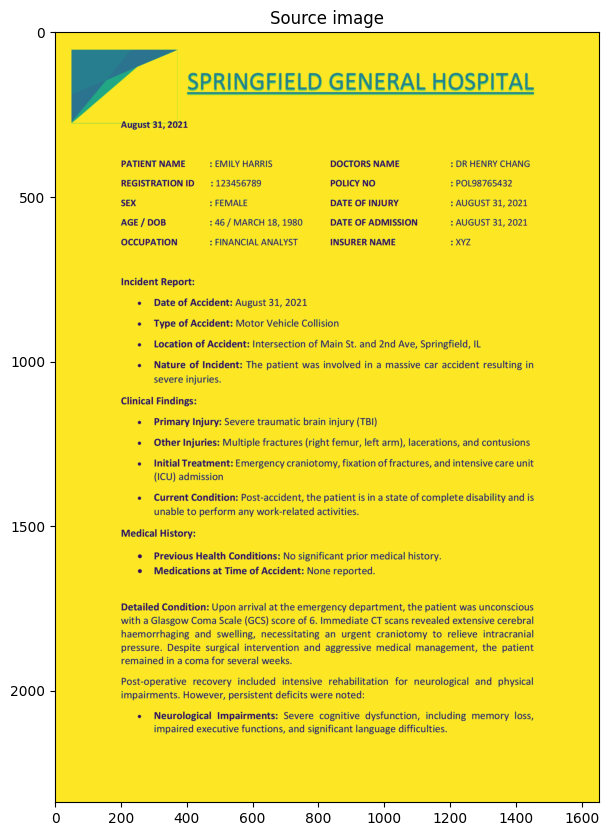

In [6]:
f, (ax1) = plt.subplots(1, 1, figsize=(8, 10))
ax1.imshow(src, vmin=0, vmax=255)
ax1.set_title("Source image")

Text(0.5, 1.0, 'Black background image')

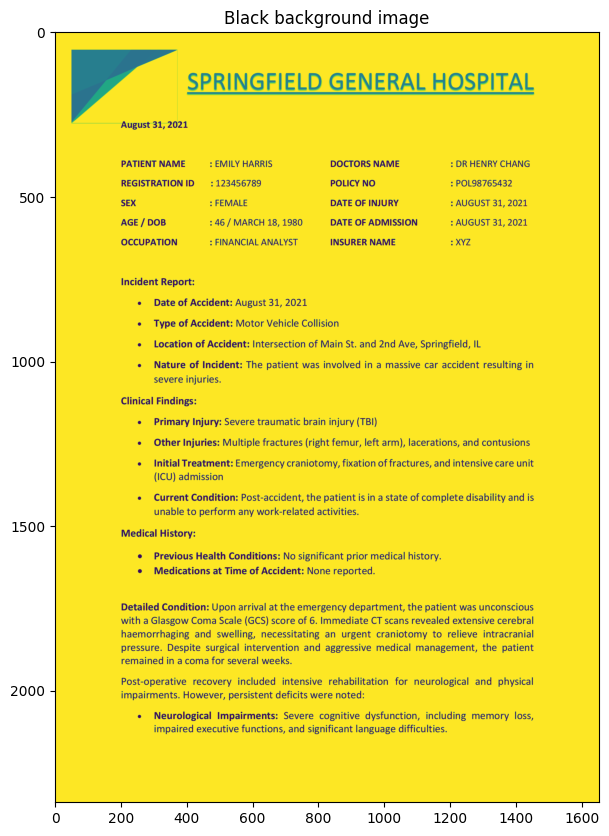

In [8]:
# Convert white to black
src[np.all(src == 255)] = 0

f, (ax1) = plt.subplots(1, 1, figsize=(8, 10))
ax1.imshow(src, vmin=0, vmax=255)
ax1.set_title("Black background image")

In [9]:
kernel = np.array([[1, 1, 1], [1, -8, 1], [1, 1, 1]], dtype=np.float32)

imgLaplacian = cv2.filter2D(src, cv2.CV_32F, kernel)
sharp = np.float32(src)
imgResult = sharp - imgLaplacian

Text(0.5, 1.0, 'Filtered image')

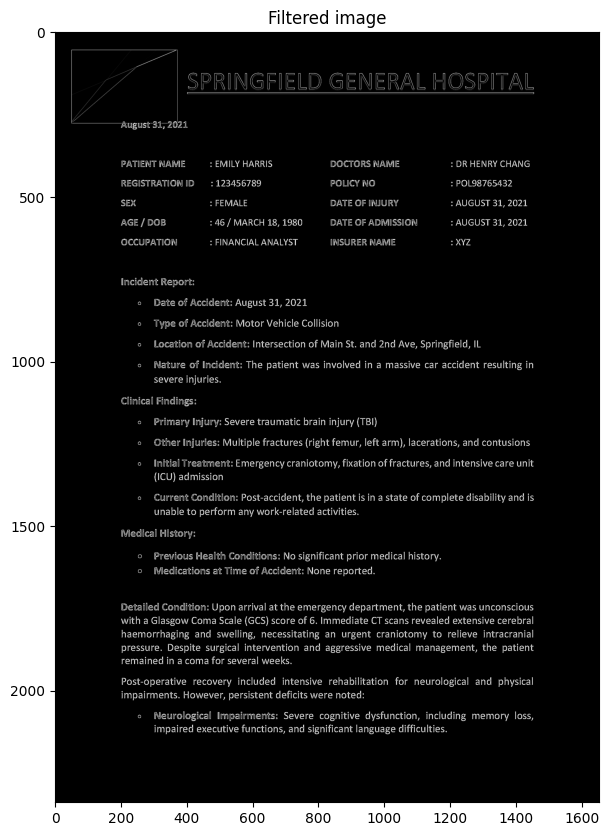

In [10]:
f, (ax1) = plt.subplots(1, 1, figsize=(8, 10))
ax1.imshow(imgLaplacian, 'gray' , vmin=0, vmax=255)
ax1.set_title("Filtered image")

Text(0.5, 1.0, 'Result image')

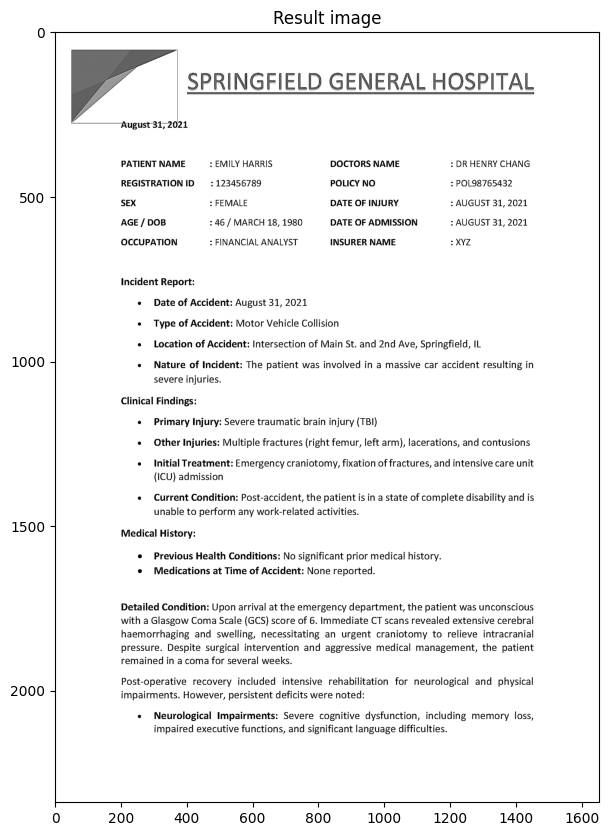

In [12]:
f, (ax1) = plt.subplots(1, 1, figsize=(8, 10))

ax1.imshow(imgResult, 'gray' , vmin=0, vmax=255)
ax1.set_title("Result image")

Text(0.5, 1.0, 'New sharpened image')

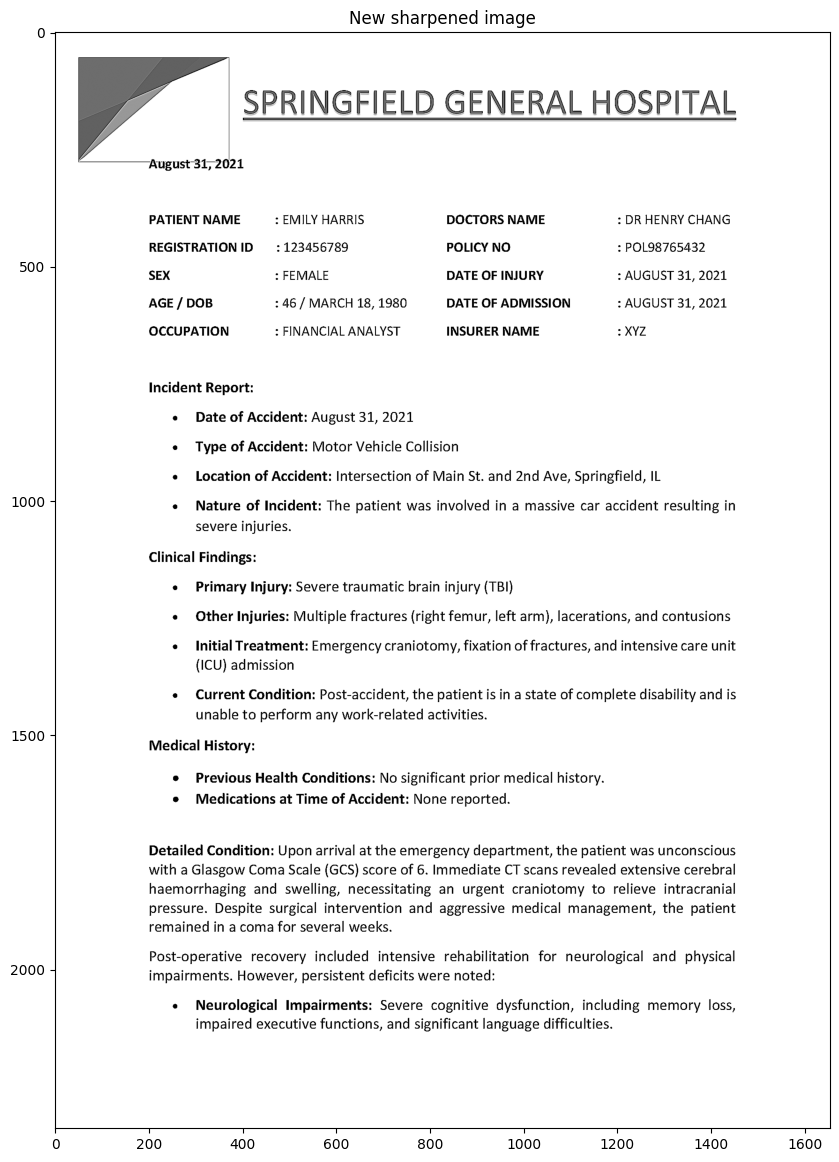

In [15]:
imgResult = np.clip(imgResult, 0, 255)
imgResult = imgResult.astype('uint8')
# imgLaplacian = np.clip(imgLaplacian, 0, 255)
# imgLaplacian = np.uint8(imgLaplacian)

f, (ax1) = plt.subplots(1, 1, figsize=(10, 20))
ax1.imshow(imgResult, 'gray' , vmin=0, vmax=255)
ax1.set_title("New sharpened image")

Text(0.5, 1.0, 'Binary image')

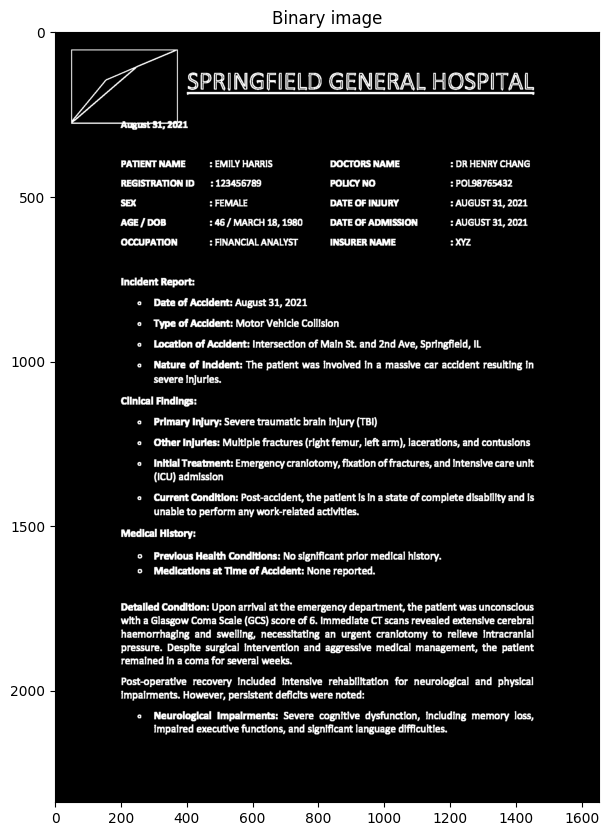

In [18]:
_, bw = cv2.threshold(imgLaplacian, 40, 255, cv2.THRESH_BINARY)
kernel1 = np.ones((3,3), dtype=np.uint8)
bw = cv2.dilate(bw, kernel1)

f, (ax1) = plt.subplots(1, 1, figsize=(8, 10))
ax1.imshow(bw, 'gray' , vmin=0, vmax=255)
ax1.set_title("Binary image")

In [ ]:
contours, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

markers = np.zeros(bw.shape, dtype=np.int32)

for i in range(len(contours)):
    cv2.drawContours(markers, contours, i, (i+1), -1)

In [ ]:
f, (ax1) = plt.subplots(1, 1, figsize=(8, 10))
ax1.imshow(markers, 'gray' , vmin=0, vmax=255)
ax1.set_title("Marked image")